## Basic Data Analysis

The first step is always to understand your data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


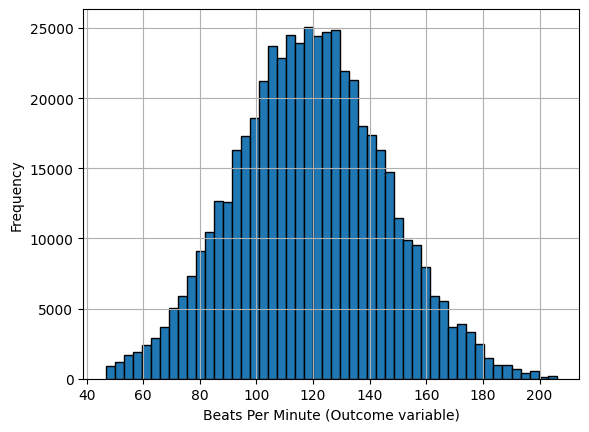

In [5]:
outcome_train = train["BeatsPerMinute"]
features_train = train.drop(columns=["BeatsPerMinute", "id"])

plt.hist(outcome_train, bins=50, edgecolor = "black")
plt.xlabel("Beats Per Minute (Outcome variable)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

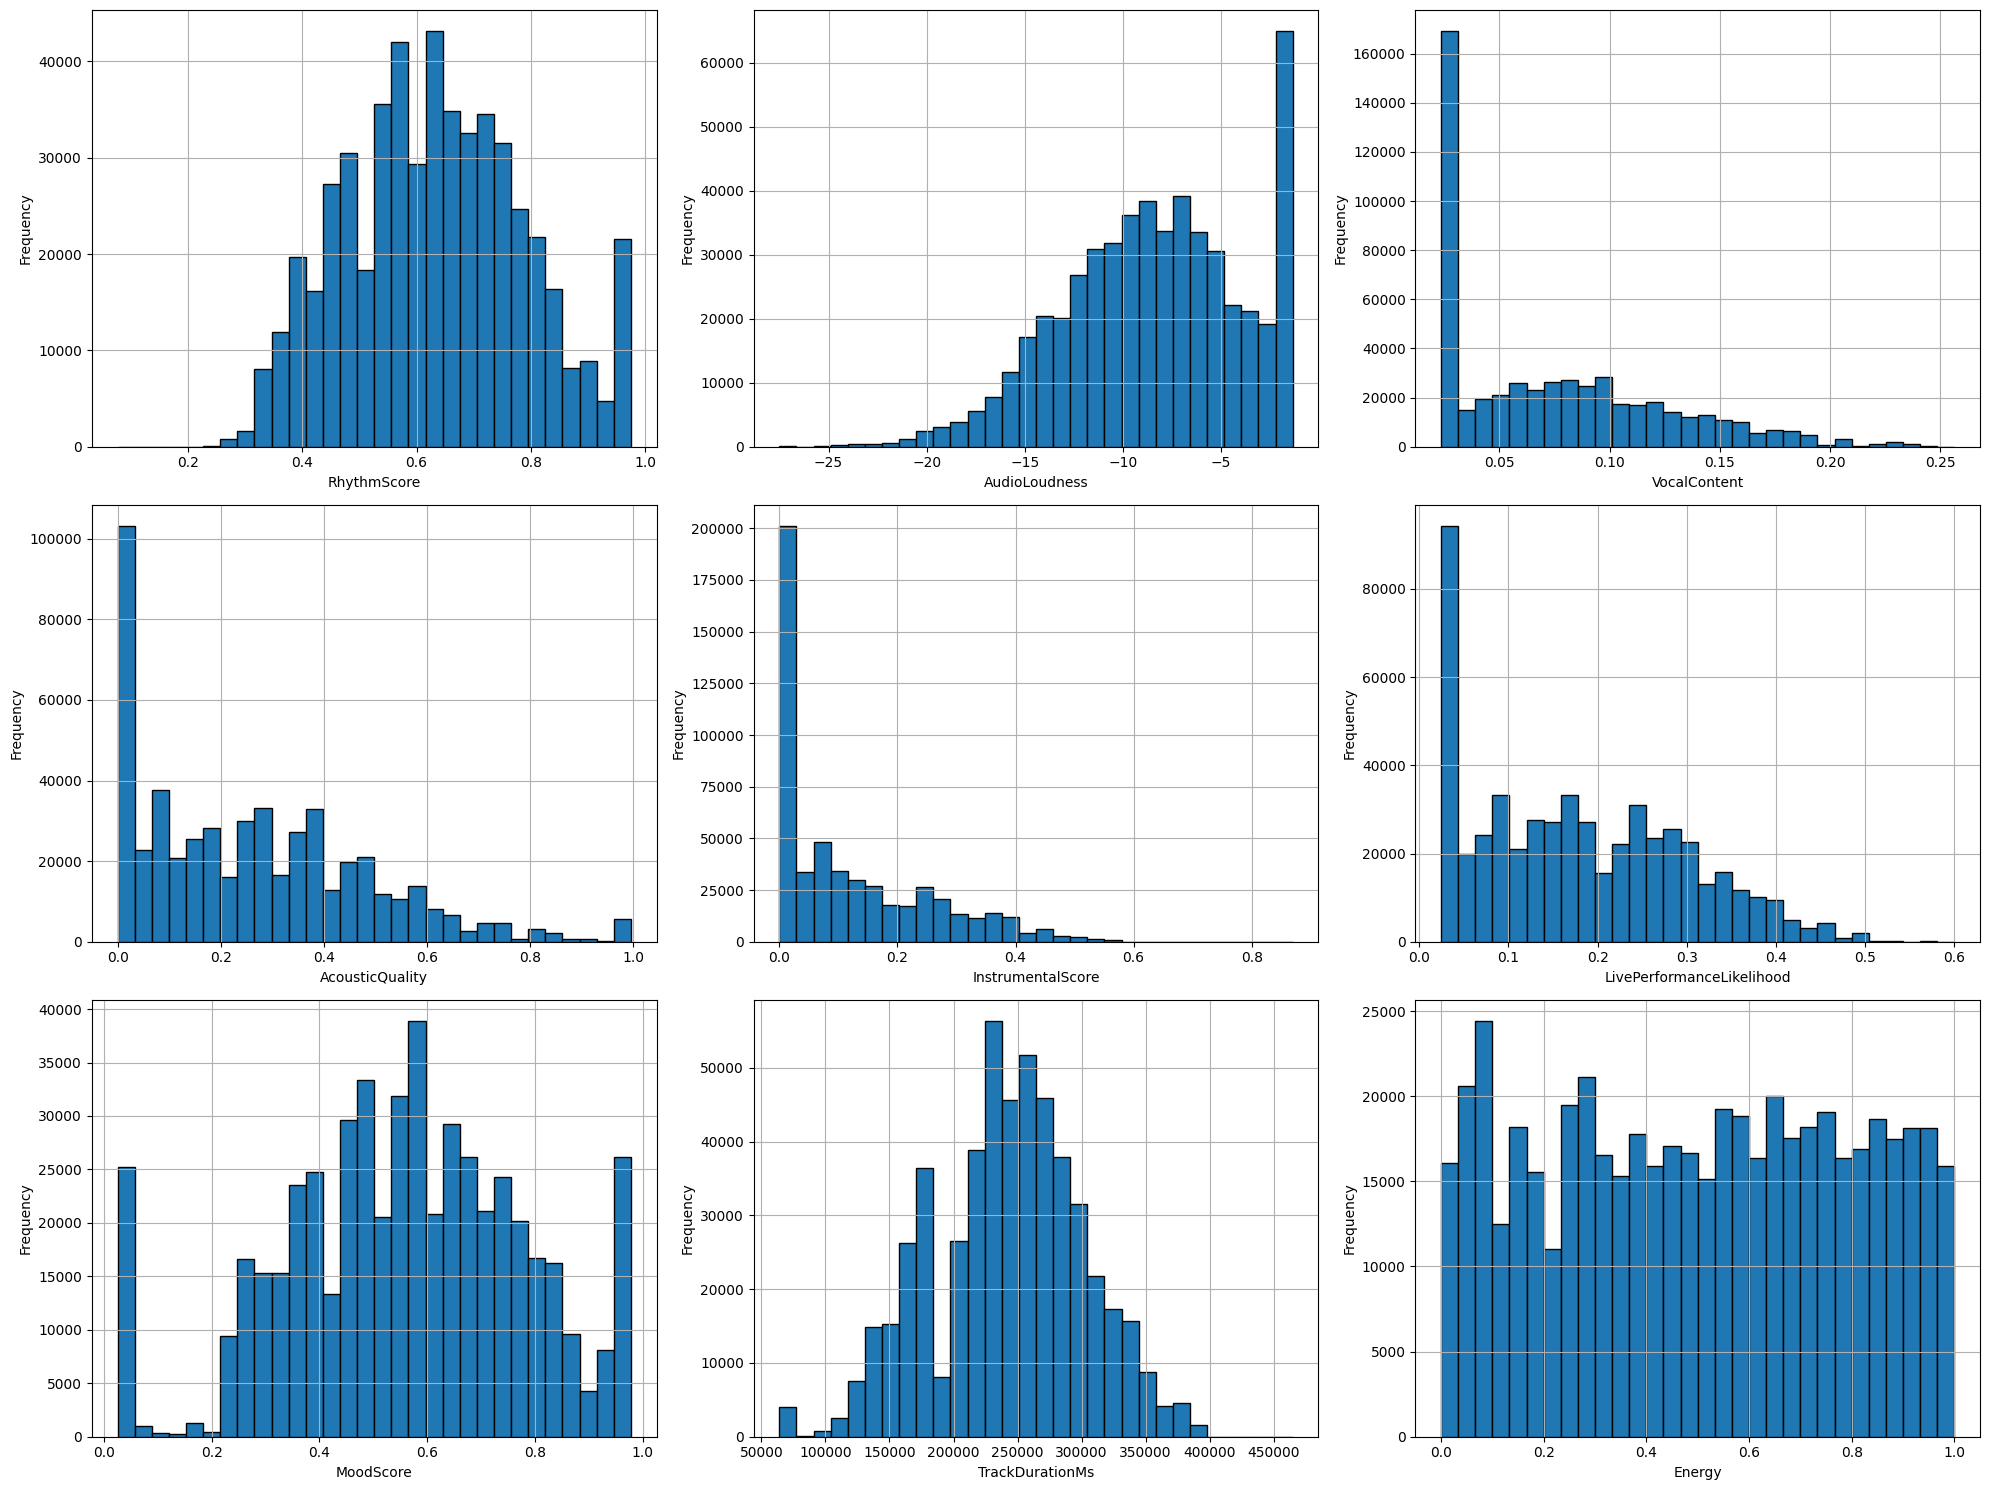

In [6]:
# frequency for all features
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(20,15))
axes = axes.flatten()
for i, col in enumerate(features_train.columns):
    ax = axes[i]
    ax.hist(features_train[col], bins = 30, edgecolor = "black")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.grid()
plt.tight_layout()
plt.show()
# correlation matrix of all features

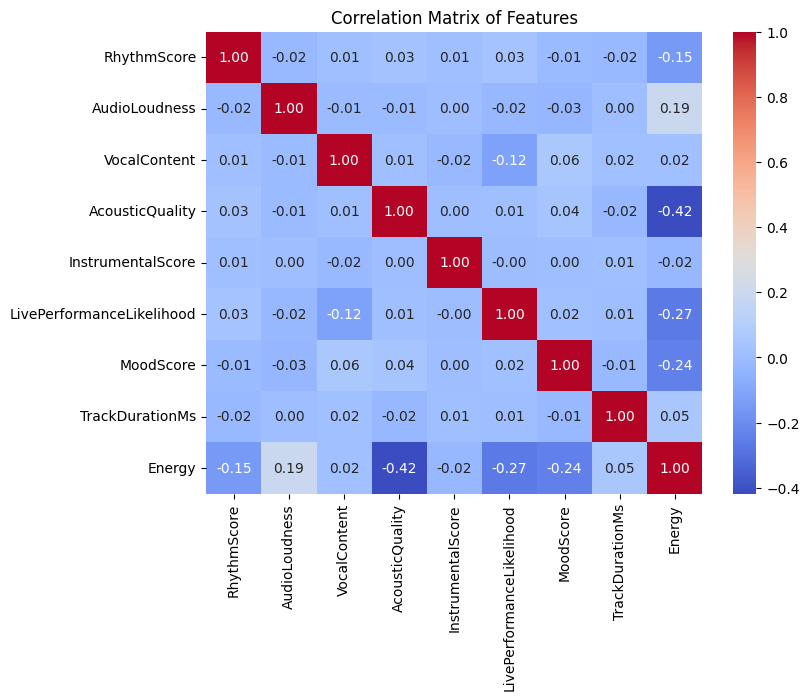

In [7]:
# correlation matrix of all features
corr = features_train.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Features")
plt.show()

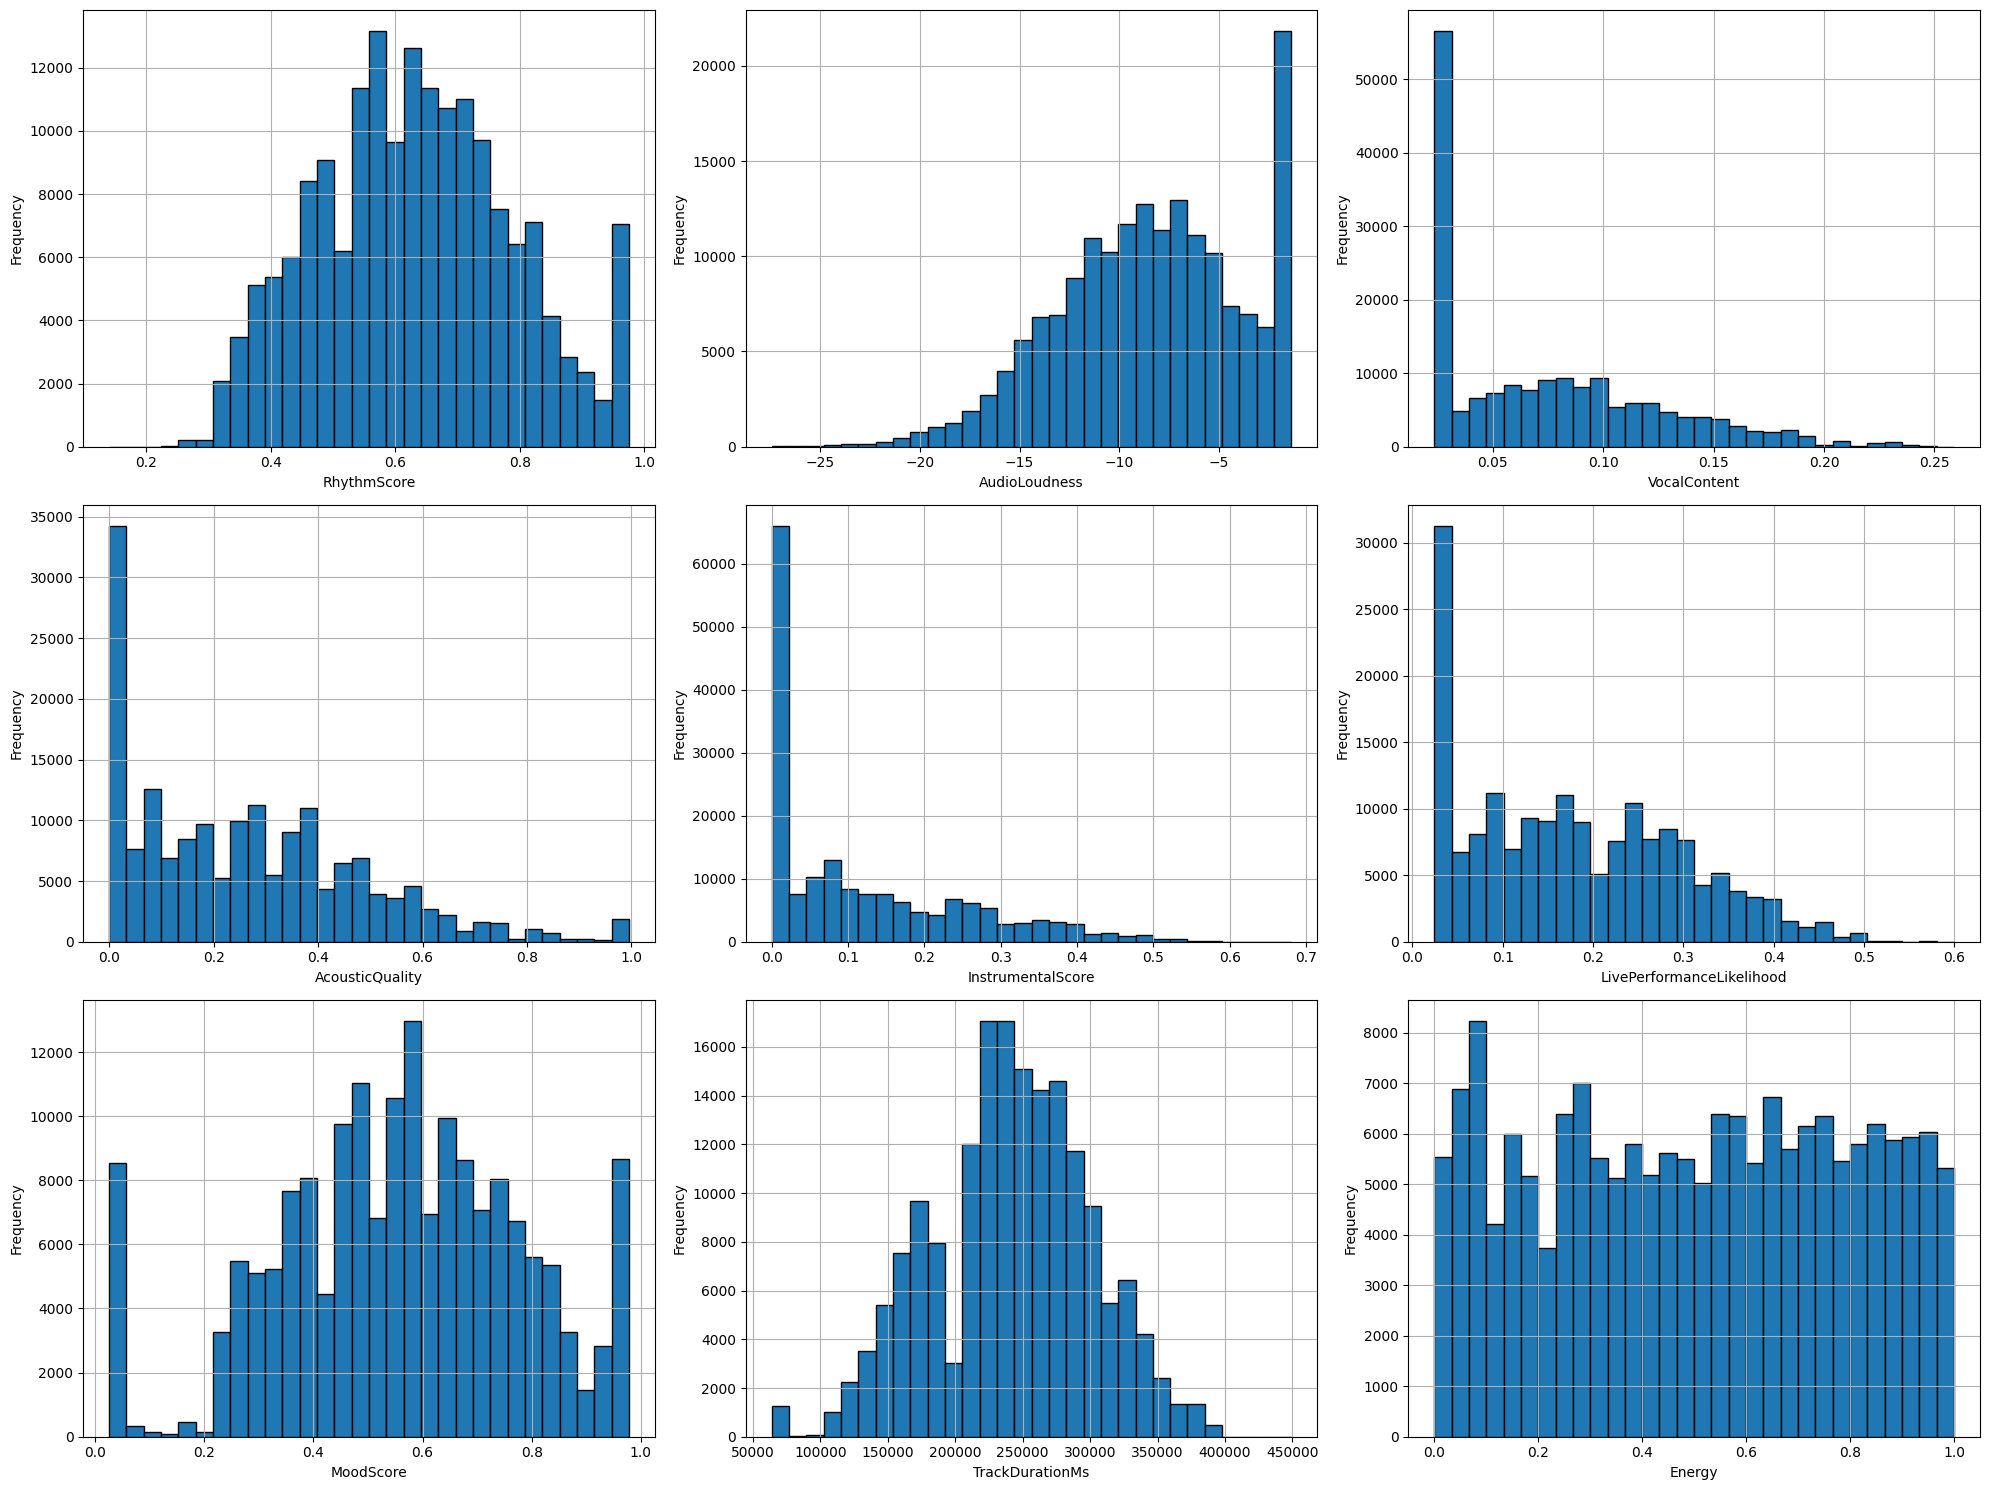

In [8]:
# same analysis with test dataset
features_test = test.drop(columns=["id"])
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(20,15))
axes = axes.flatten()
for i, col in enumerate(features_test.columns):
    ax = axes[i]
    ax.hist(features_test[col], bins = 30, edgecolor = "black")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.grid()
plt.tight_layout()
plt.show()

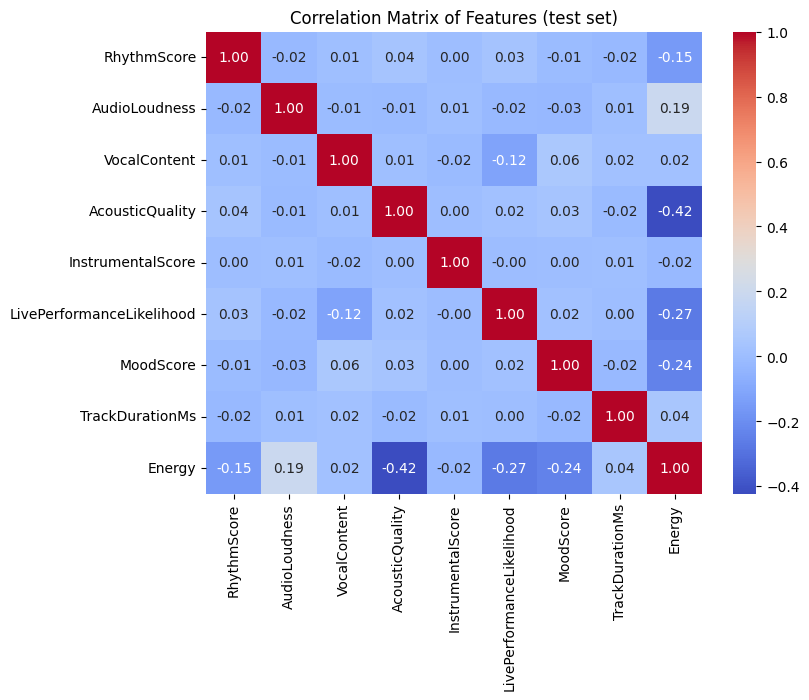

In [9]:
# correlation matrix for test set
corr_test = features_test.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_test, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Features (test set)")
plt.show()

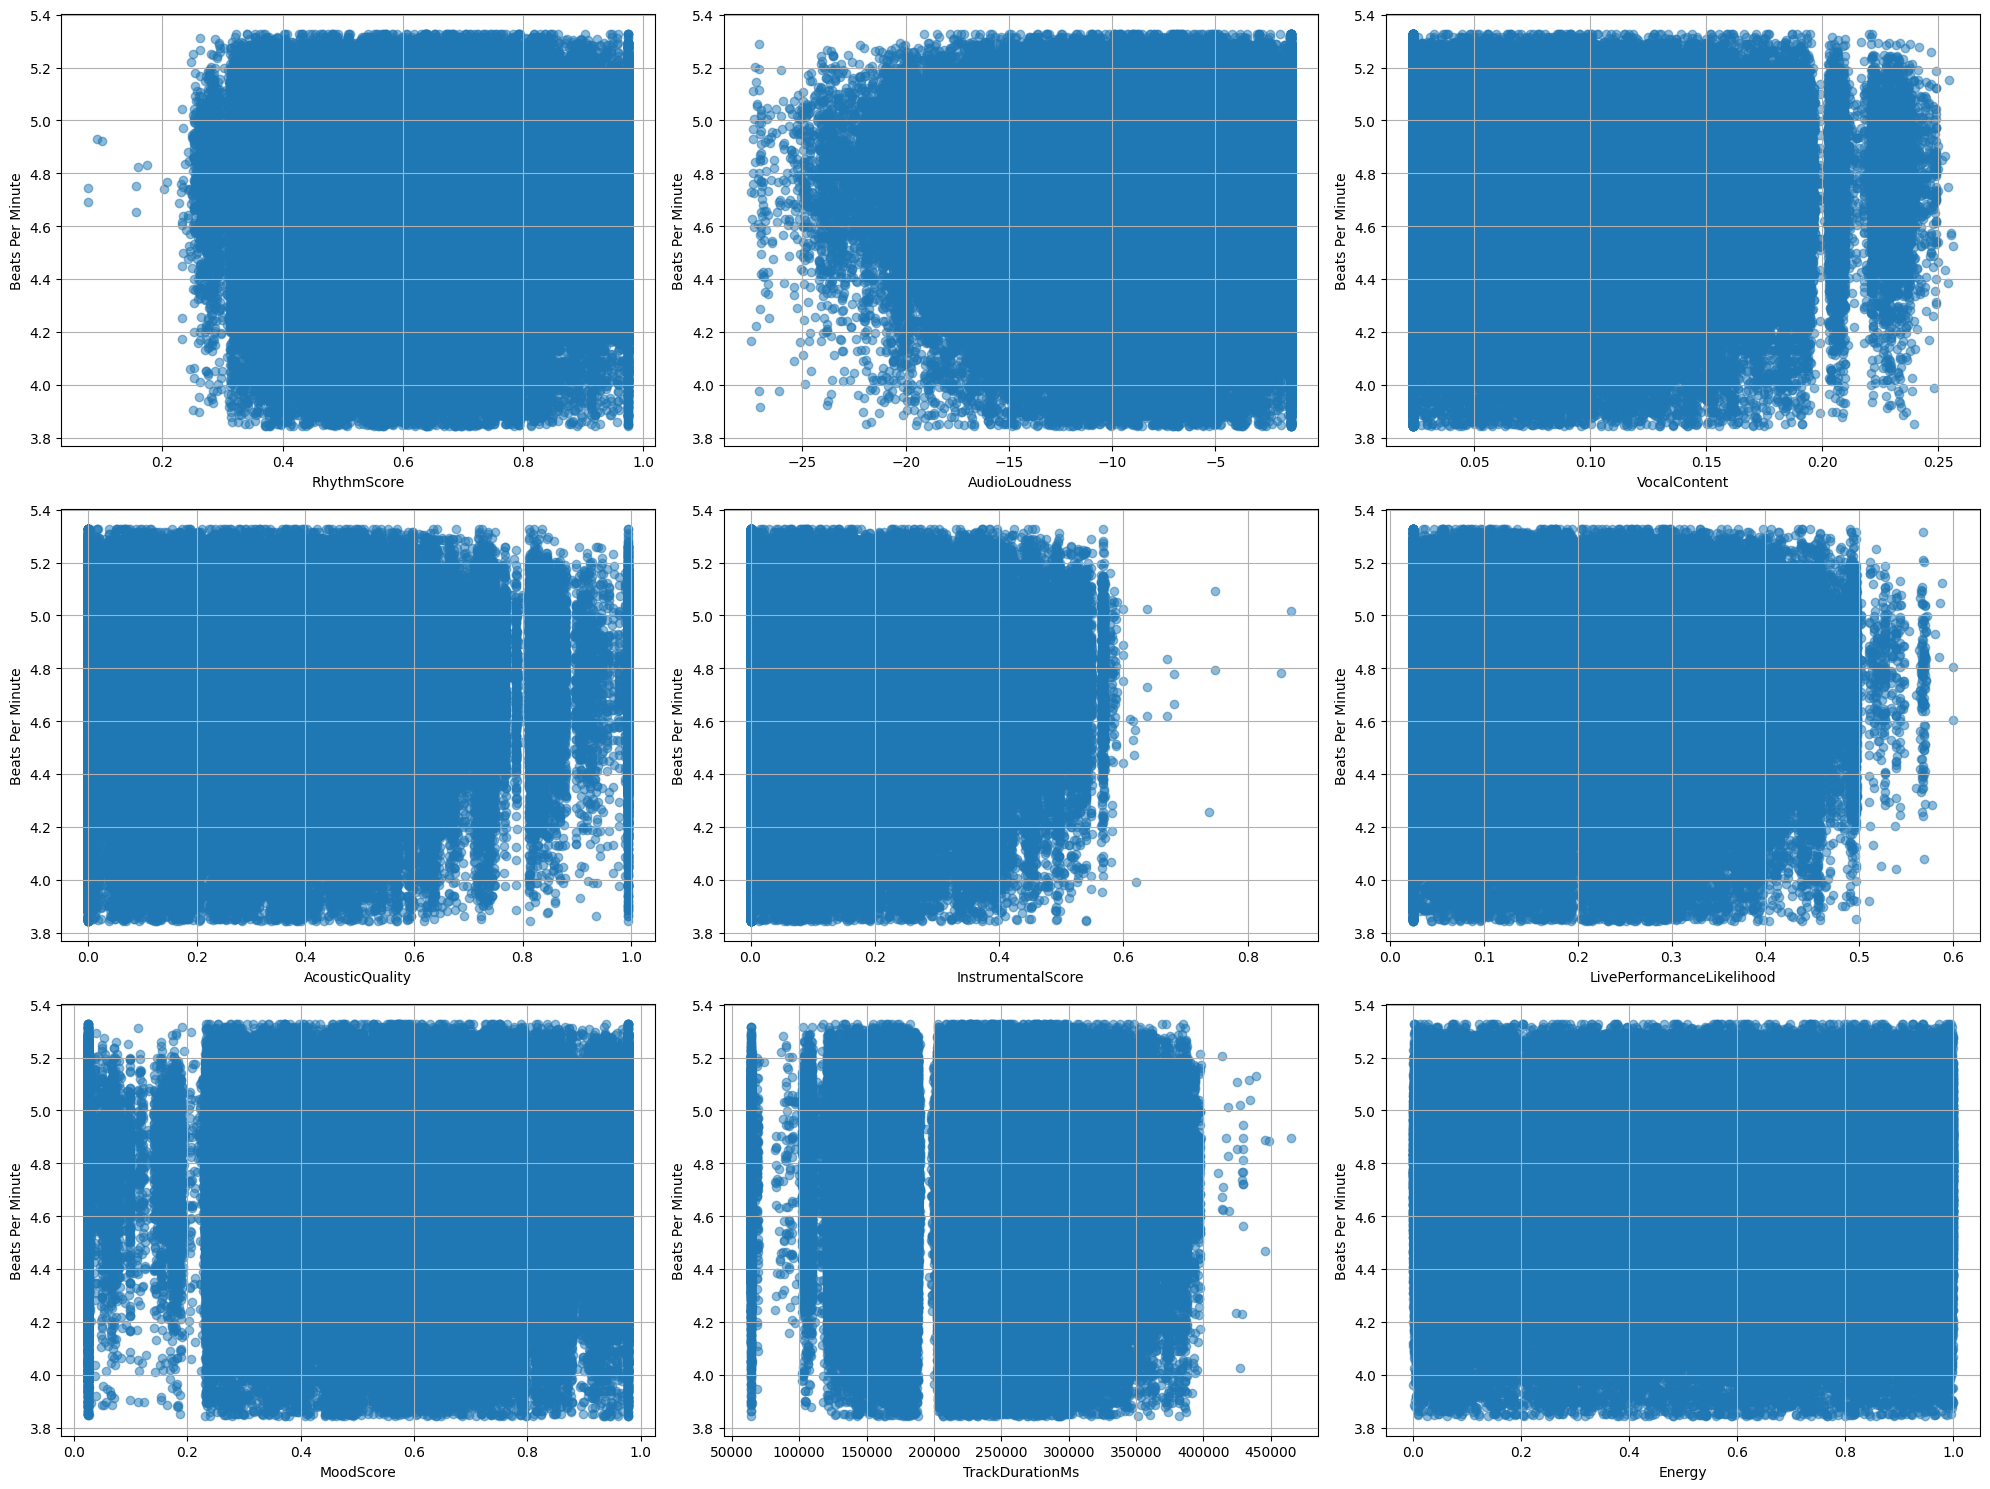

In [18]:
# relationship with outcome
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(20,15))
axes = axes.flatten()
for i, col in enumerate(features_train.columns):
    ax = axes[i]
    ax.scatter(features_train[col], np.log(outcome_train), alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel("Beats Per Minute")
    ax.grid()
plt.tight_layout()
plt.show()

In [39]:
## TODO: experiment with feature engineering, interaction term and scaling.
# sin function
def sine_transform(x):
    return np.sin(x)

# log function
def log_transform(x):
    return np.log1p(x)

# interaction term
def interaction_term(x, y):
    return x * y

# scaling function
def scale_feature(x):
    return (x - np.mean(x)) / np.std(x)

# logit transform skewed features
logit_features = features_train.copy()
skewed_cols = ["AcousticQuality", "Energy", "RhythmScore", "MoodScore"]
for col in skewed_cols:
    logit_features[col + "_logit"] = log_transform(logit_features[col])
    logit_features[col + "_logit"] = scale_feature(logit_features[col + "_logit"])
    logit_features.drop(columns=[col], inplace=True)
logit_features.head()


,AudioLoudness,VocalContent,InstrumentalScore,LivePerformanceLikelihood,TrackDurationMs,AcousticQuality_logit,Energy_logit,RhythmScore_logit,MoodScore_logit
0,-7.636942,0.023500,0.000001,0.051385,290715.6450,-1.285378,1.082902,-0.139793,-0.575159
1,-16.267598,0.071520,0.349414,0.170522,164519.5174,0.878609,-1.260400,0.090003,0.464118
2,-15.953575,0.110715,0.453814,0.029576,174495.5667,-0.343745,0.495362,-0.733886,-0.510126
3,-1.357000,0.052965,0.159717,0.086366,225567.4651,-1.275711,0.052197,0.675667,-1.217681
4,-13.056437,0.023500,0.000001,0.331345,213960.6789,-0.894828,1.405310,-0.608140,-0.265541


In [45]:
# scale all features first
scaled_features = features_train.apply(scale_feature)

# apply transformations
log_features = pd.DataFrame()
sin_features = pd.DataFrame()
for col in scaled_features.columns:
    log_features[f"{col}"] = log_transform(scaled_features[col])
    sin_features[f"{col}_sin"] = sine_transform(scaled_features[col])
print(log_features.head())
print(sin_features.head())


   RhythmScore  AudioLoudness  VocalContent  AcousticQuality  \
0    -0.206189       0.149069           NaN              NaN   
1     0.041254            NaN     -0.060324         0.596514   
2    -1.402514            NaN      0.545995        -0.510571   
3     0.499364       0.924720     -0.562286              NaN   
4    -1.012125            NaN           NaN        -2.044062   

   InstrumentalScore  LivePerformanceLikelihood  MoodScore  TrackDurationMs  \
0          -2.231529                        NaN  -1.042436         0.600356   
1           1.014344                  -0.068965   0.352110              NaN   
2           1.266778                        NaN  -0.880251              NaN   
3           0.276693                  -1.508290        NaN        -0.322082   
4          -2.231529                   0.830352  -0.425041        -0.636774   

     Energy  
0  0.752388  
1       NaN  
2  0.355416  
3 -0.047519  
4  0.932007  
   RhythmScore_sin  AudioLoudness_sin  VocalContent_sin 

c:\Users\tangx\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tangx\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tangx\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tangx\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tangx\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr

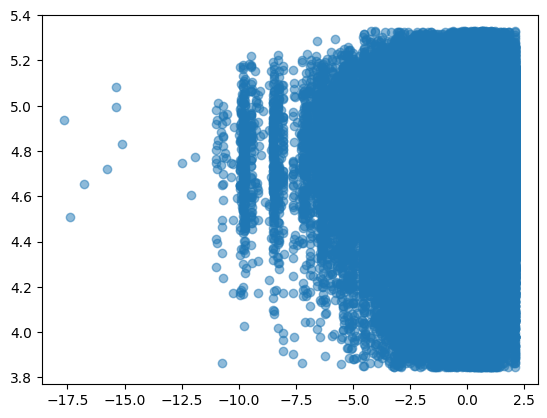

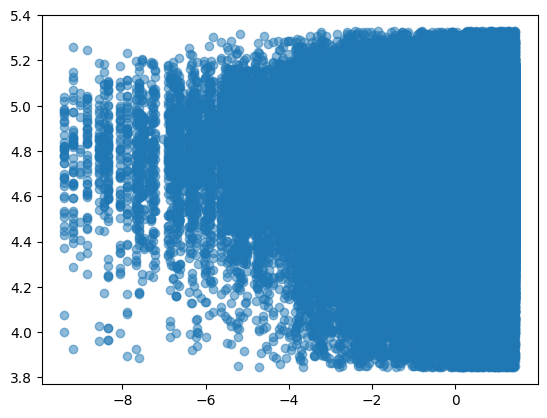

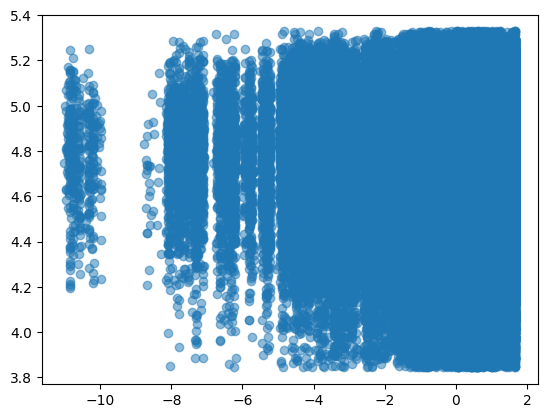

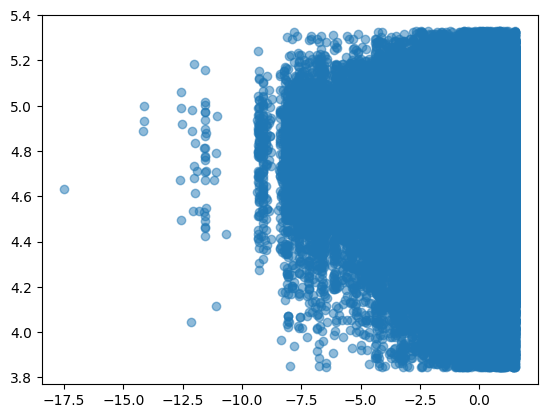

In [34]:
# relationship with outcome
plt.scatter(log_features["AcousticQuality_log"], np.log(outcome_train), alpha=0.5)
plt.show()
plt.scatter(log_features["Energy_log"], np.log(outcome_train), alpha=0.5)
plt.show()
plt.scatter(log_features["RhythmScore_log"], np.log(outcome_train), alpha=0.5)
plt.show()
plt.scatter(log_features["MoodScore_log"], np.log(outcome_train), alpha=0.5)

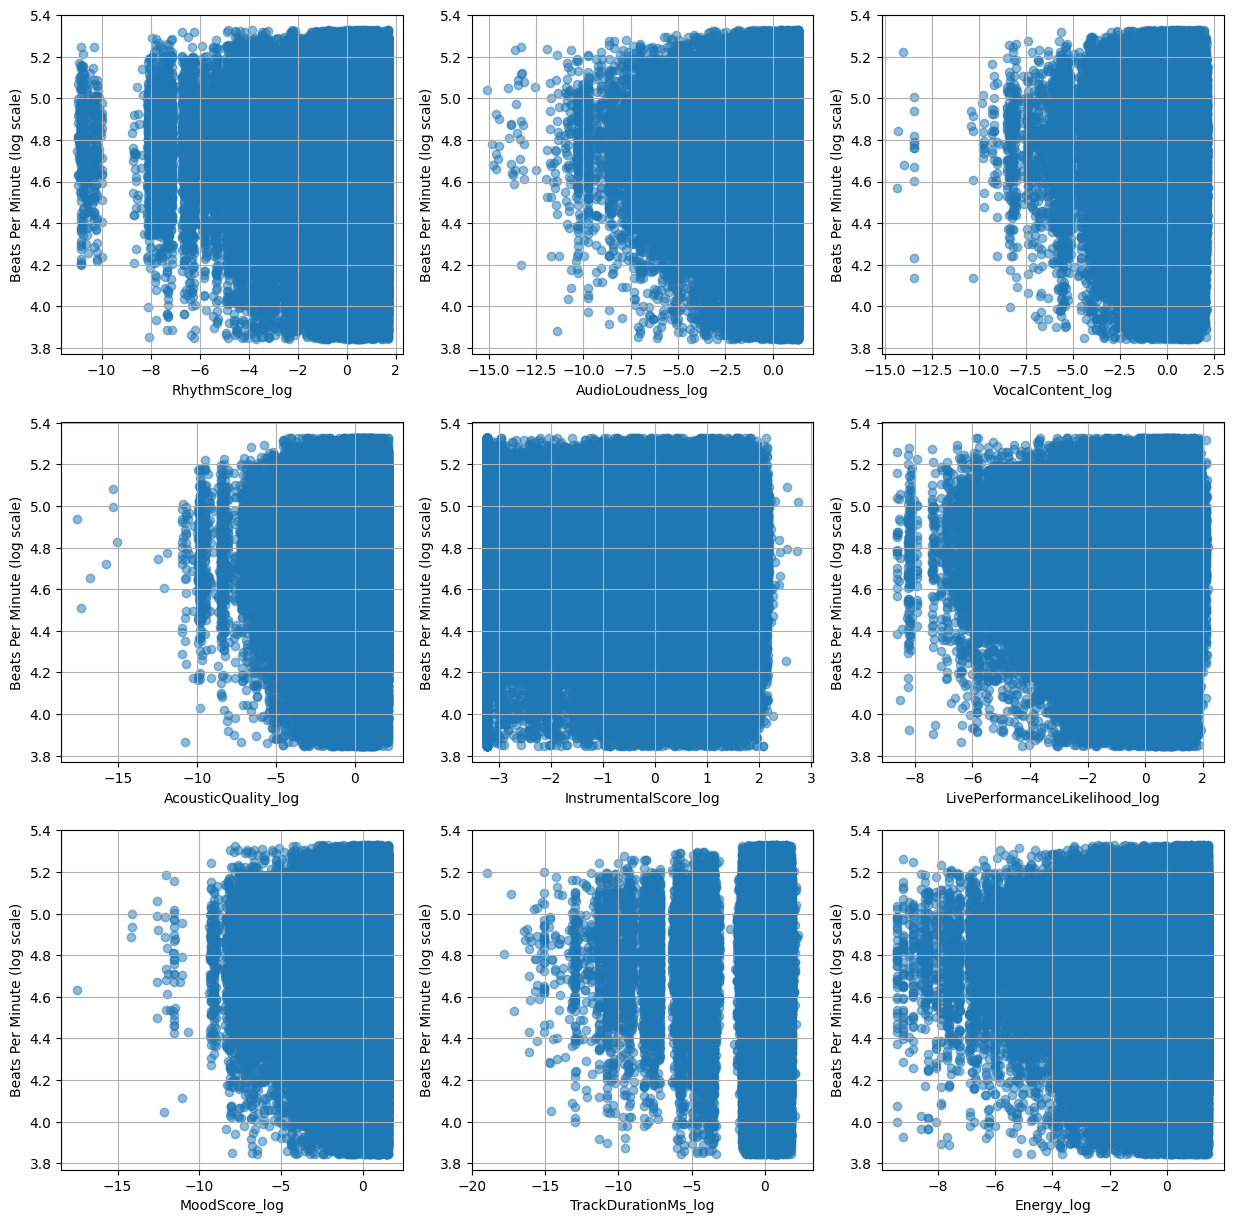

In [35]:
# plot logit transformed features against outcome
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(15, 15))
for i, col in enumerate(log_features.columns):
    ax = axes.flatten()[i]
    ax.scatter(log_features[col], np.log(outcome_train), alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel("Beats Per Minute (log scale)")
    ax.grid()
plt.show()

In [46]:
# save log_transformed training set
log_train = log_features.copy()
log_train["BeatsPerMinute"] = outcome_train
log_train  = log_train.dropna()
print(log_train.head())
log_train.to_csv("log_transformed_training_set.csv", index=False)

    RhythmScore  AudioLoudness  VocalContent  AcousticQuality  \
10     0.094113       0.374537      0.108370        -0.909827   
14     0.060083       0.924720     -0.944404         0.712889   
17    -1.072440       0.924720      0.655752         0.118242   
18     0.777205       0.924720      0.647406        -0.714848   
19     0.119938       0.042919     -0.533329        -0.073845   

    InstrumentalScore  LivePerformanceLikelihood  MoodScore  TrackDurationMs  \
10           0.109335                   0.596209   0.534436         0.245396   
14           0.745322                   0.517298  -0.360492        -0.814030   
17          -0.930041                   0.662815  -3.150946         0.024047   
18          -2.231529                   0.400009   0.443483         0.172348   
19          -2.231529                   0.539182   0.349377         0.661361   

      Energy  BeatsPerMinute  
10 -0.669606       131.35937  
14  0.835016       145.92435  
17 -0.103296        95.88081  
18  